Note: This code was completed with the aid of LLMs. All final decisions on implementation and core ideas are my own. LLMs were primarily used to bug fix, increase effiencincy (especially for cleaning and reading the data due to large file sizes), push code faster, and point me in the direction of various methods which I then researched prior to coding with the help of an LLM.

# Reading and Cleaning Data

In [ ]:
import os
%cd "/content/drive/MyDrive/data"

In [ ]:
import zipfile
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow
import pyarrow.parquet as pq
import seaborn as sns
from google.colab import drive
from scipy import stats

In [ ]:
# set up paths
print("direct ssd extraction method")

drive.mount('/content/drive', force_remount=False)
drive_data_dir = "/content/drive/MyDrive/data"
ssd_dir = "/tmp/uspto_uncompressed"
os.makedirs(ssd_dir, exist_ok=True)

db_path = os.path.join(ssd_dir, "clean_pipeline.db")
if os.path.exists(db_path):
    os.remove(db_path)

con = duckdb.connect(db_path)
con.execute("SET memory_limit = '4GB';")
con.execute("SET threads = 2;")

# unzip directly to local ssd
def extract_zip_to_ssd(zip_name):
    zip_path = os.path.join(drive_data_dir, zip_name)
    print(f"extracting {zip_name} to local ssd disk")
    with zipfile.ZipFile(zip_path, 'r') as z:
        extracted_fname = z.namelist()[0]
        z.extractall(ssd_dir)
    extracted_path = os.path.join(ssd_dir, extracted_fname)
    print(f"saved uncompressed: {extracted_fname}")
    return extracted_path

# load and sample cohort
dta_path = os.path.join(drive_data_dir, "patentvc_enhanced_4var.dta")
print("loading target cohort")
df_stata = pd.read_stata(dta_path)
con.register("df_stata_temp", df_stata)

con.execute("""
    CREATE OR REPLACE TABLE filtered_2000_2020 AS
    SELECT
        CAST(patent_number AS VARCHAR) AS patent_id,
        CAST(application_date AS DATE) AS application_date,
        CAST(grant_date AS DATE) AS grant_date,
        EXTRACT(YEAR FROM CAST(grant_date AS DATE)) AS grant_year,
        EXTRACT(YEAR FROM CAST(application_date AS DATE)) AS app_year,
        VC AS vc_backed
    FROM df_stata_temp
    WHERE EXTRACT(YEAR FROM CAST(grant_date AS DATE)) BETWEEN 2000 AND 2020;

    CREATE OR REPLACE TABLE target_patents AS
    SELECT * FROM filtered_2000_2020
    USING SAMPLE 500000 (reservoir);

    DROP TABLE filtered_2000_2020;
""")

del df_stata
con.unregister("df_stata_temp")

sample_count = con.execute("SELECT COUNT(*) FROM target_patents;").fetchone()[0]
print(f"target cohort: {sample_count:,} patents (2000-2020)")

# process cpc classes
cpc_file = extract_zip_to_ssd("g_cpc_current.tsv.zip")
print("processing cpc classes")

con.execute(f"""
    CREATE OR REPLACE TABLE target_cpcs AS
    SELECT
        p.patent_id,
        FIRST(CAST(c.cpc_section AS VARCHAR)) AS cpc_section,
        FIRST(CAST(c.cpc_subclass AS VARCHAR)) AS cpc_subclass
    FROM target_patents p
    INNER JOIN read_csv('{cpc_file}', header=True, delim='\t', all_varchar=True, ignore_errors=True) c
       ON p.patent_id = c.patent_id
    GROUP BY p.patent_id;
""")

os.remove(cpc_file)
print("cpc classes matched")

# process citations
cite_file = extract_zip_to_ssd("g_us_patent_citation.tsv.zip")
print("processing citations on local ssd")

con.execute(f"""
    CREATE OR REPLACE TABLE raw_citations AS
    SELECT
        CAST(patent_id AS VARCHAR) AS focal_id,
        CAST(citation_patent_id AS VARCHAR) AS cited_id
    FROM read_csv('{cite_file}', header=True, delim='\t', all_varchar=True, ignore_errors=True);

    CREATE OR REPLACE TABLE target_backward_cites AS
    SELECT p.patent_id, COUNT(DISTINCT c.cited_id) AS backward_pat_citations
    FROM target_patents p
    INNER JOIN raw_citations c ON p.patent_id = c.focal_id
    GROUP BY p.patent_id;

    CREATE OR REPLACE TABLE target_forward_cites_raw AS
    SELECT p.patent_id, COUNT(DISTINCT c.focal_id) AS raw_forward_citations
    FROM target_patents p
    INNER JOIN raw_citations c ON p.patent_id = c.cited_id
    GROUP BY p.patent_id;

    DROP TABLE raw_citations;
""")

os.remove(cite_file)
print("citation networks matched")

# process npl
npl_file = extract_zip_to_ssd("g_other_reference.tsv.zip")
print("processing non-patent literature")

con.execute(f"""
    CREATE OR REPLACE TABLE target_npl_cites AS
    SELECT
        p.patent_id,
        COUNT(DISTINCT n.other_reference_text) AS npl_citations
    FROM target_patents p
    INNER JOIN read_csv('{npl_file}', header=True, delim='\t', all_varchar=True, ignore_errors=True) n
       ON p.patent_id = n.patent_id
    GROUP BY p.patent_id;
""")

os.remove(npl_file)
print("non-patent literature matched")

# process assignees
assignee_file = extract_zip_to_ssd("g_assignee_disambiguated.tsv.zip")
print("processing assignees")

con.execute(f"""
    CREATE OR REPLACE TABLE target_assignees AS
    SELECT
        p.patent_id,
        FIRST(CAST(a.disambig_assignee_organization AS VARCHAR)) AS assignee_organization,
        FIRST(CAST(a.assignee_type AS VARCHAR)) AS assignee_type
    FROM target_patents p
    INNER JOIN read_csv('{assignee_file}', header=True, delim='\t', all_varchar=True, ignore_errors=True) a
       ON p.patent_id = a.patent_id
    GROUP BY p.patent_id;
""")

os.remove(assignee_file)
print("assignees matched")

# master assembly
print("assembling final step1_metrics table")

con.execute("""
    CREATE OR REPLACE TABLE step1_metrics AS
    SELECT
        p.*,
        COALESCE(cpc.cpc_section, 'UNKNOWN') AS cpc_section,
        COALESCE(cpc.cpc_subclass, 'UNKNOWN') AS cpc_subclass,
        COALESCE(b.backward_pat_citations, 0) AS backward_pat_citations,
        COALESCE(f.raw_forward_citations, 0) AS raw_forward_citations,
        COALESCE(n.npl_citations, 0) AS npl_citations,
        a.assignee_organization,
        a.assignee_type
    FROM target_patents p
    LEFT JOIN target_cpcs cpc ON p.patent_id = cpc.patent_id
    LEFT JOIN target_backward_cites b ON p.patent_id = b.patent_id
    LEFT JOIN target_forward_cites_raw f ON p.patent_id = f.patent_id
    LEFT JOIN target_npl_cites n ON p.patent_id = n.patent_id
    LEFT JOIN target_assignees a ON p.patent_id = a.patent_id;
""")

step1_parquet = os.path.join(drive_data_dir, "step1_metrics.parquet")
con.execute(f"COPY step1_metrics TO '{step1_parquet}' (FORMAT PARQUET);")

print(f"step 1 complete. saved to drive: {step1_parquet}")

In [ ]:
# setup and paths
print("step 2: duckdb parquet conversion")

drive.mount('/content/drive', force_remount=False)
drive_data_dir = "/content/drive/MyDrive/data"
ssd_dir = "/tmp/uspto_uncompressed"
os.makedirs(ssd_dir, exist_ok=True)

step1_parquet = os.path.join(drive_data_dir, "step1_metrics.parquet")
claims_zip_path = os.path.join(drive_data_dir, "patent_claims_stats.dta.zip")

# init duckdb
db_path = os.path.join(ssd_dir, "step2_temp.db")
if os.path.exists(db_path):
    os.remove(db_path)

con = duckdb.connect(db_path)
con.execute("SET memory_limit = '4GB';")
con.execute("SET threads = 2;")

# unzip and prepare lookup keys
print("unzipping claims dataset to local ssd")
with zipfile.ZipFile(claims_zip_path, 'r') as z:
    extracted_dta = z.namelist()[0]
    z.extractall(ssd_dir)

local_dta_path = os.path.join(ssd_dir, extracted_dta)

print("building target lookup table")
con.execute(f"""
    CREATE OR REPLACE TABLE target_keys AS
    SELECT DISTINCT
        CAST(patent_id AS VARCHAR) AS original_patent_id,
        TRIM(CAST(patent_id AS VARCHAR)) AS exact_key,
        REGEXP_REPLACE(LTRIM(REGEXP_REPLACE(CAST(patent_id AS VARCHAR), '^0+', ''), '0'), '[^0-9]', '', 'g') AS clean_numeric_key
    FROM '{step1_parquet}';
""")

target_count = con.execute("SELECT COUNT(*) FROM target_keys;").fetchone()[0]
print(f"loaded {target_count:,} target patent ids")

# convert stata to local parquet via pyarrow
print("converting stata file to fast local parquet")
local_claims_parquet = os.path.join(ssd_dir, "claims_raw.parquet")

if os.path.exists(local_claims_parquet):
    os.remove(local_claims_parquet)

reader = pd.read_stata(local_dta_path, chunksize=5000000)
writer = None

for i, chunk in enumerate(reader):
    chunk['pat_no'] = chunk['pat_no'].astype(str)
    table = pyarrow.Table.from_pandas(chunk)
    if writer is None:
        writer = pq.ParquetWriter(local_claims_parquet, table.schema)
    writer.write_table(table)
    print(f"converted {(i + 1) * 5:,} million rows to disk")

if writer is not None:
    writer.close()

os.remove(local_dta_path)

# duckdb parquet join
print("claims dataset converted. executing sql join")
con.execute(f"""
    CREATE OR REPLACE TABLE matched_claims AS
    SELECT
        t.original_patent_id AS patent_id,
        c.* EXCLUDE (pat_no)
    FROM '{local_claims_parquet}' c
    INNER JOIN target_keys t
       ON TRIM(c.pat_no) = t.exact_key
       OR REGEXP_REPLACE(LTRIM(TRIM(c.pat_no), '0'), '[^0-9]', '', 'g') = t.clean_numeric_key;
""")

total_matches = con.execute("SELECT COUNT(*) FROM matched_claims;").fetchone()[0]
print(f"total matched claims: {total_matches:,}")

# save output and clean up
if total_matches > 0:
    step2_parquet = os.path.join(drive_data_dir, "step2_claims.parquet")
    con.execute(f"COPY matched_claims TO '{step2_parquet}' (FORMAT PARQUET);")
    print(f"saved to drive: {step2_parquet}")

os.remove(local_claims_parquet)

In [ ]:
# setup and paths
print("step 2: pre-indexed duckdb join")

drive.mount('/content/drive', force_remount=False)
drive_data_dir = "/content/drive/MyDrive/data"
ssd_dir = "/tmp/uspto_uncompressed"

step1_parquet = os.path.join(drive_data_dir, "step1_metrics.parquet")
local_claims_parquet = os.path.join(ssd_dir, "claims_raw.parquet")

if not os.path.exists(local_claims_parquet):
    raise FileNotFoundError("local claims_raw.parquet missing")

con = duckdb.connect()
con.execute("SET threads = 2;")

# build fast target key index
print("building fast target key index")
con.execute(f"""
    CREATE OR REPLACE TABLE target_keys AS
    SELECT DISTINCT
        CAST(patent_id AS VARCHAR) AS original_patent_id,
        REGEXP_REPLACE(LTRIM(REGEXP_REPLACE(CAST(patent_id AS VARCHAR), '^0+', ''), '0'), '[^0-9]', '', 'g') AS clean_key
    FROM '{step1_parquet}';
""")

# pre-clean claims keys and inner join
print("executing pre-indexed high-speed join")
con.execute(f"""
    CREATE OR REPLACE TABLE matched_claims AS
    WITH cleaned_claims AS (
        SELECT
            *,
            REGEXP_REPLACE(LTRIM(TRIM(pat_no), '0'), '[^0-9]', '', 'g') AS clean_key
        FROM '{local_claims_parquet}'
    )
    SELECT
        t.original_patent_id AS patent_id,
        c.* EXCLUDE (pat_no, clean_key)
    FROM cleaned_claims c
    INNER JOIN target_keys t ON c.clean_key = t.clean_key;
""")

total_matches = con.execute("SELECT COUNT(*) FROM matched_claims;").fetchone()[0]
print(f"total matched claims: {total_matches:,}")

# export to drive and clean ssd
if total_matches > 0:
    step2_parquet = os.path.join(drive_data_dir, "step2_claims.parquet")
    con.execute(f"COPY matched_claims TO '{step2_parquet}' (FORMAT PARQUET);")
    print(f"saved to drive: {step2_parquet}")

if os.path.exists(local_claims_parquet):
    os.remove(local_claims_parquet)

In [ ]:
import os
import duckdb
from google.colab import drive

# setup and paths
print("step 3: sector normalization and master panel assembly")

drive.mount('/content/drive', force_remount=False)
drive_data_dir = "/content/drive/MyDrive/data"

step1_parquet = os.path.join(drive_data_dir, "step1_metrics.parquet")
step2_parquet = os.path.join(drive_data_dir, "step2_claims.parquet")

if not os.path.exists(step1_parquet) or not os.path.exists(step2_parquet):
    raise FileNotFoundError("missing intermediate files")

con = duckdb.connect()
con.execute("SET threads = 2;")

print("loading datasets into duckdb")
con.execute(f"""
    CREATE OR REPLACE TABLE step1_data AS SELECT * FROM '{step1_parquet}';
    CREATE OR REPLACE TABLE step2_data AS SELECT * FROM '{step2_parquet}';
""")

# aggregate patent claims
print("aggregating claims to patent-level metrics")
con.execute("""
    CREATE OR REPLACE TABLE claims_aggregated AS
    SELECT
        patent_id,
        COUNT(claim_no) AS total_claims,
        AVG(word_ct) AS avg_words_per_claim,
        SUM(word_ct) AS total_claim_words,
        MAX(CASE WHEN ind_flg = '1' THEN 1 ELSE 0 END) AS has_independent_claims
    FROM step2_data
    GROUP BY patent_id;
""")

# cpc subclass x grant year benchmarking
print("computing cpc subclass x grant year benchmarks")
con.execute("""
    CREATE OR REPLACE TABLE cpc_year_benchmarks AS
    SELECT
        cpc_subclass,
        grant_year,
        AVG(raw_forward_citations) AS mean_cell_forward_cites,
        COUNT(*) AS cell_patent_count
    FROM step1_data
    GROUP BY cpc_subclass, grant_year;

    CREATE OR REPLACE TABLE master_patent_panel AS
    SELECT
        s1.*,
        CAST(s1.npl_citations AS FLOAT) / NULLIF(s1.backward_pat_citations + s1.npl_citations, 0) AS npl_ratio,
        s1.raw_forward_citations / NULLIF(bm.mean_cell_forward_cites, 0) AS normalized_forward_citations,
        bm.mean_cell_forward_cites AS peer_benchmark_mean_cites,
        COALESCE(cl.total_claims, 0) AS total_claims,
        COALESCE(cl.avg_words_per_claim, 0) AS avg_words_per_claim,
        COALESCE(cl.total_claim_words, 0) AS total_claim_words,
        COALESCE(cl.has_independent_claims, 0) AS has_independent_claims
    FROM step1_data s1
    LEFT JOIN cpc_year_benchmarks bm
        ON s1.cpc_subclass = bm.cpc_subclass AND s1.grant_year = bm.grant_year
    LEFT JOIN claims_aggregated cl
        ON s1.patent_id = cl.patent_id;
""")

# export master panel
output_csv_path = os.path.join(drive_data_dir, "cleaned_patent_panel.csv")
output_parquet_path = os.path.join(drive_data_dir, "cleaned_patent_panel.parquet")

print("exporting master panel to drive")
con.execute(f"COPY master_patent_panel TO '{output_csv_path}' (HEADER, DELIMITER ',');")
con.execute(f"COPY master_patent_panel TO '{output_parquet_path}' (FORMAT PARQUET);")

# clean up intermediate files
if os.path.exists(step1_parquet):
    os.remove(step1_parquet)
if os.path.exists(step2_parquet):
    os.remove(step2_parquet)

final_count = con.execute("SELECT COUNT(*) FROM master_patent_panel;").fetchone()[0]

print("phase 1 complete")
print(f"master cohort patents: {final_count:,}")
print(f"saved parquet: {output_parquet_path}")
print(f"saved csv: {output_csv_path}")

# Visualizations

In [4]:
# data set information

# setup paths and load data
drive_data_dir = "/content/drive/MyDrive/data"
parquet_path = os.path.join(drive_data_dir, "cleaned_patent_panel.parquet")

con = duckdb.connect()

df = con.execute(f"""
    SELECT
        patent_id,
        vc_backed,
        grant_year,
        normalized_forward_citations,
        npl_ratio,
        total_claims,
        LN(total_claims + 1) AS log_claims
    FROM '{parquet_path}'
    WHERE grant_year BETWEEN 2000 AND 2020;
""").df()

# dataset summary and variable definitions
print("# dataset summary and variable definitions\n")
print(f"# total observations: {len(df):,} patents")
print(f"# time period: {df['grant_year'].min()} - {df['grant_year'].max()} grant years")
print("# source: uspto database matched with venture capital records\n")

print("# variables")
print("# patent_id: unique patent identifier")
print("# vc_backed: 1 if assignee received venture capital, 0 otherwise")
print("# grant_year: calendar year patent was granted")
print("# normalized_forward_citations: focal citations divided by mean of cpc subclass and grant year cohort")
print("# npl_ratio: non-patent literature / (backward citations + non-patent literature)")
print("# total_claims: count of patent claims")
print("# log_claims: ln(total_claims + 1)\n")

# summary statistics
stats_cols = ['normalized_forward_citations', 'npl_ratio', 'total_claims']
summary = df[stats_cols].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]

print("# summary statistics")
print("# variable                      count    mean  std dev   min   25%   50%   75%     max")
for var, row in summary.iterrows():
    print(
        f"# {var:<28} "
        f"{row['count']:8.2f} "
        f"{row['mean']:5.2f} "
        f"{row['std']:8.2f} "
        f"{row['min']:5.2f} "
        f"{row['25%']:5.2f} "
        f"{row['50%']:5.2f} "
        f"{row['75%']:5.2f} "
        f"{row['max']:7.2f}"
    )

# group mean comparisons (welch's t-test)
print("\n# group mean comparisons (welch's t-test)")

vc_group = df[df['vc_backed'] == 1]
non_vc_group = df[df['vc_backed'] == 0]

for var in ['normalized_forward_citations', 'total_claims', 'npl_ratio']:
    vc_clean = vc_group[var].dropna()
    non_vc_clean = non_vc_group[var].dropna()

    t_stat, p_val = stats.ttest_ind(vc_clean, non_vc_clean, equal_var=False)

    p_format = f"{p_val:.4f}" if p_val >= 0.001 else f"{p_val:.2e}"

    print(f"\n# {var}")
    print(f"# vc-backed mean: {vc_clean.mean():.3f} (n = {len(vc_clean)})")
    print(f"# non-vc mean:    {non_vc_clean.mean():.3f} (n = {len(non_vc_clean)})")
    print(f"# t-statistic:    {t_stat:.2f}")
    print(f"# p-value:        {p_format}")

# dataset summary and variable definitions

# total observations: 500,000 patents
# time period: 2000 - 2020 grant years
# source: uspto database matched with venture capital records

# variables
# patent_id: unique patent identifier
# vc_backed: 1 if assignee received venture capital, 0 otherwise
# grant_year: calendar year patent was granted
# normalized_forward_citations: focal citations divided by mean of cpc subclass and grant year cohort
# npl_ratio: non-patent literature / (backward citations + non-patent literature)
# total_claims: count of patent claims
# log_claims: ln(total_claims + 1)

# summary statistics
# variable                      count    mean  std dev   min   25%   50%   75%     max
# normalized_forward_citations  8012.00  1.00     2.56  0.00  0.00  0.23  1.09  111.47
# npl_ratio                     7871.00  0.37     0.35  0.00  0.00  0.29  0.67    1.00
# total_claims                 500000.00 16.15    14.08  0.00  7.00 14.00 21.00  683.00

# group mean comparisons

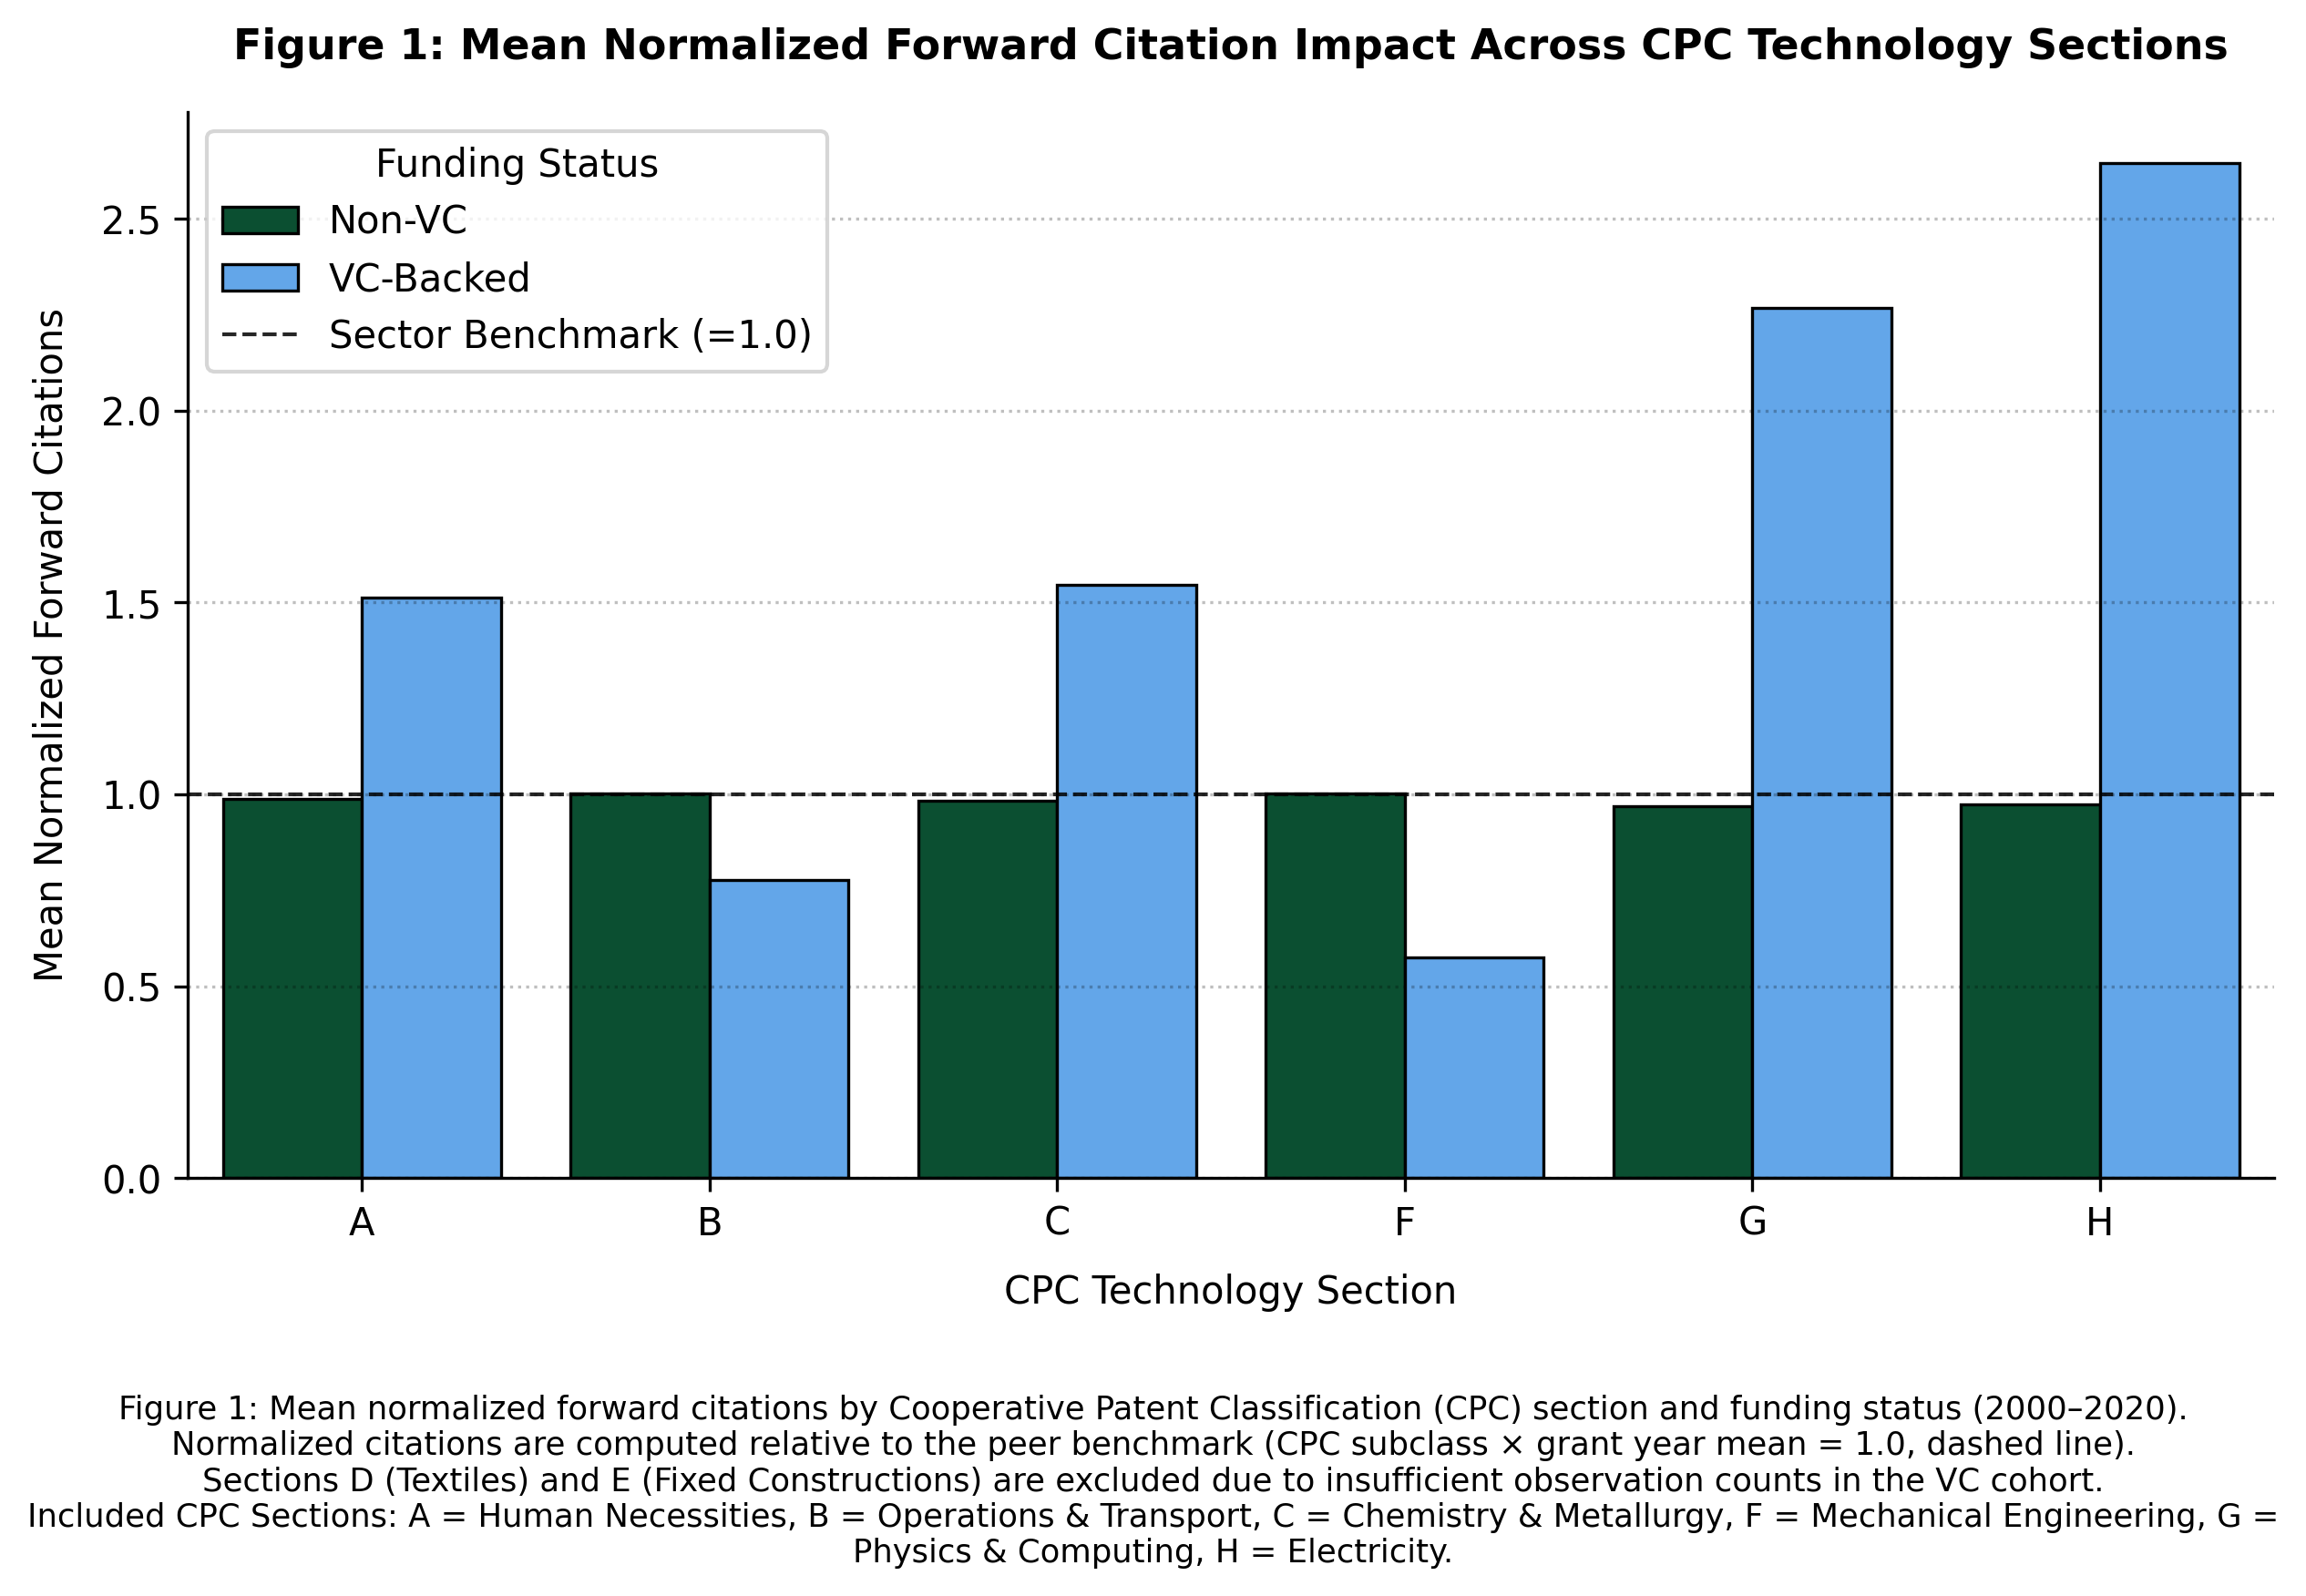

In [12]:
rive_data_dir = "/content/drive/MyDrive/data"
parquet_path = os.path.join(drive_data_dir, "cleaned_patent_panel.parquet")

con = duckdb.connect()
df_sec = con.execute(f"""
    SELECT
        cpc_section,
        CASE WHEN vc_backed = 1 THEN 'VC-Backed' ELSE 'Non-VC' END AS vc_status,
        AVG(normalized_forward_citations) AS mean_citations,
        COUNT(*) AS patent_count
    FROM '{parquet_path}'
    WHERE cpc_section IS NOT NULL
      AND cpc_section NOT IN ('UNKNOWN', 'D', 'E')
    GROUP BY cpc_section, vc_backed
    ORDER BY cpc_section;
""").df()

plt.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#000000',
    'grid.color': '#000000',
    'grid.alpha': 0.25
})

fig, ax = plt.subplots(figsize=(8.5, 5), dpi=300)

sns.barplot(
    data=df_sec,
    x='cpc_section',
    y='mean_citations',
    hue='vc_status',
    palette={'VC-Backed': '#4da6ff', 'Non-VC': '#005a32'},
    edgecolor='#000000',
    linewidth=0.8,
    ax=ax
)

ax.axhline(1.0, color='#000000', linestyle='--', linewidth=1.0, alpha=0.85, label='Sector Benchmark (=1.0)')

ax.set_title('Figure 1: Mean Normalized Forward Citation Impact Across CPC Technology Sections', fontsize=11, fontweight='bold', pad=14)
ax.set_xlabel('CPC Technology Section', fontsize=10, labelpad=8)
ax.set_ylabel('Mean Normalized Forward Citations', fontsize=10, labelpad=8)
ax.grid(True, linestyle=':', axis='y')

ax.legend(title='Funding Status', frameon=True, loc='upper left')

caption = (
    "Figure 1: Mean normalized forward citations by Cooperative Patent Classification (CPC) section and funding status (2000–2020).\n"
    "Normalized citations are computed relative to the peer benchmark (CPC subclass × grant year mean = 1.0, dashed line).\n"
    "Sections D (Textiles) and E (Fixed Constructions) are excluded due to insufficient observation counts in the VC cohort.\n"
    "Included CPC Sections: A = Human Necessities, B = Operations & Transport, C = Chemistry & Metallurgy, "
    "F = Mechanical Engineering, G = Physics & Computing, H = Electricity."
)
plt.figtext(0.5, -0.15, caption, wrap=True, horizontalalignment='center', fontsize=8.5, color='#000000')

plt.tight_layout()

fig1_path = os.path.join(drive_data_dir, "figure1_cpc_section_citations.png")
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()

In [6]:
#figure 2

# setup paths and load data
drive_data_dir = "/content/drive/MyDrive/data"
parquet_path = os.path.join(drive_data_dir, "cleaned_patent_panel.parquet")

con = duckdb.connect()
df_plot = con.execute(f"""
    SELECT
        vc_backed,
        npl_ratio,
        LN(total_claims + 1) AS log_claims
    FROM '{parquet_path}'
    WHERE grant_year BETWEEN 2000 AND 2020;
""").df()

df_plot['vc_status'] = df_plot['vc_backed'].map({1: 'vc-backed', 0: 'non-vc'})

# styling configuration
plt.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.3,
    'grid.color': '#000000',
    'axes.edgecolor': '#000000'
})

palette = {'vc-backed': '#4da6ff', 'non-vc': '#005a32'}

# figure 2a: science intensity density
fig_2a, ax_2a = plt.subplots(figsize=(7, 4.5), dpi=300)

sns.kdeplot(
    data=df_plot,
    x='npl_ratio',
    hue='vc_status',
    fill=True,
    common_norm=False,
    palette=palette,
    ax=ax_2a,
    alpha=0.3,
    linewidth=1.1
)

ax_2a.set_title('empirical distribution of science intensity', fontsize=11, fontweight='bold', pad=12, color='#000000')
ax_2a.set_xlabel('npl ratio [npl / (backward citations + npl)]', fontsize=10, color='#000000')
ax_2a.set_ylabel('density', fontsize=10, color='#000000')
ax_2a.set_xlim(0, 1.0)
ax_2a.grid(True, linestyle=':')

caption_2a = (
    "figure 2a: empirical distribution of science intensity comparing vc-backed and non-vc patents (2000–2020).\n"
    "science intensity is defined as the ratio of non-patent literature citations to total backward citations."
)
plt.figtext(0.5, -0.12, caption_2a, wrap=True, horizontalalignment='center', fontsize=8.5, color='#000000')

plt.tight_layout()
fig_2a_path = os.path.join(drive_data_dir, "figure2a_science_intensity.png")
plt.savefig(fig_2a_path, dpi=300, bbox_inches='tight')
plt.close(fig_2a)
print(f"saved figure 2a: {fig_2a_path}")

# figure 2b: patent scope density
fig_2b, ax_2b = plt.subplots(figsize=(7, 4.5), dpi=300)

sns.kdeplot(
    data=df_plot,
    x='log_claims',
    hue='vc_status',
    fill=True,
    common_norm=False,
    palette=palette,
    ax=ax_2b,
    alpha=0.3,
    linewidth=1.1
)

ax_2b.set_title('empirical distribution of patent scope', fontsize=11, fontweight='bold', pad=12, color='#000000')
ax_2b.set_xlabel('log(total claims + 1)', fontsize=10, color='#000000')
ax_2b.set_ylabel('density', fontsize=10, color='#000000')
ax_2b.grid(True, linestyle=':')

caption_2b = (
    "figure 2b: empirical distribution of patent scope comparing vc-backed and non-vc patents (2000–2020).\n"
    "patent scope is proxied by the natural logarithm of total claim count plus one to adjust for skewness."
)
plt.figtext(0.5, -0.12, caption_2b, wrap=True, horizontalalignment='center', fontsize=8.5, color='#000000')

plt.tight_layout()
fig_2b_path = os.path.join(drive_data_dir, "figure2b_patent_scope.png")
plt.savefig(fig_2b_path, dpi=300, bbox_inches='tight')
plt.close(fig_2b)
print(f"saved figure 2b: {fig_2b_path}")

saved figure 2a: /content/drive/MyDrive/data/figure2a_science_intensity.png
saved figure 2b: /content/drive/MyDrive/data/figure2b_patent_scope.png


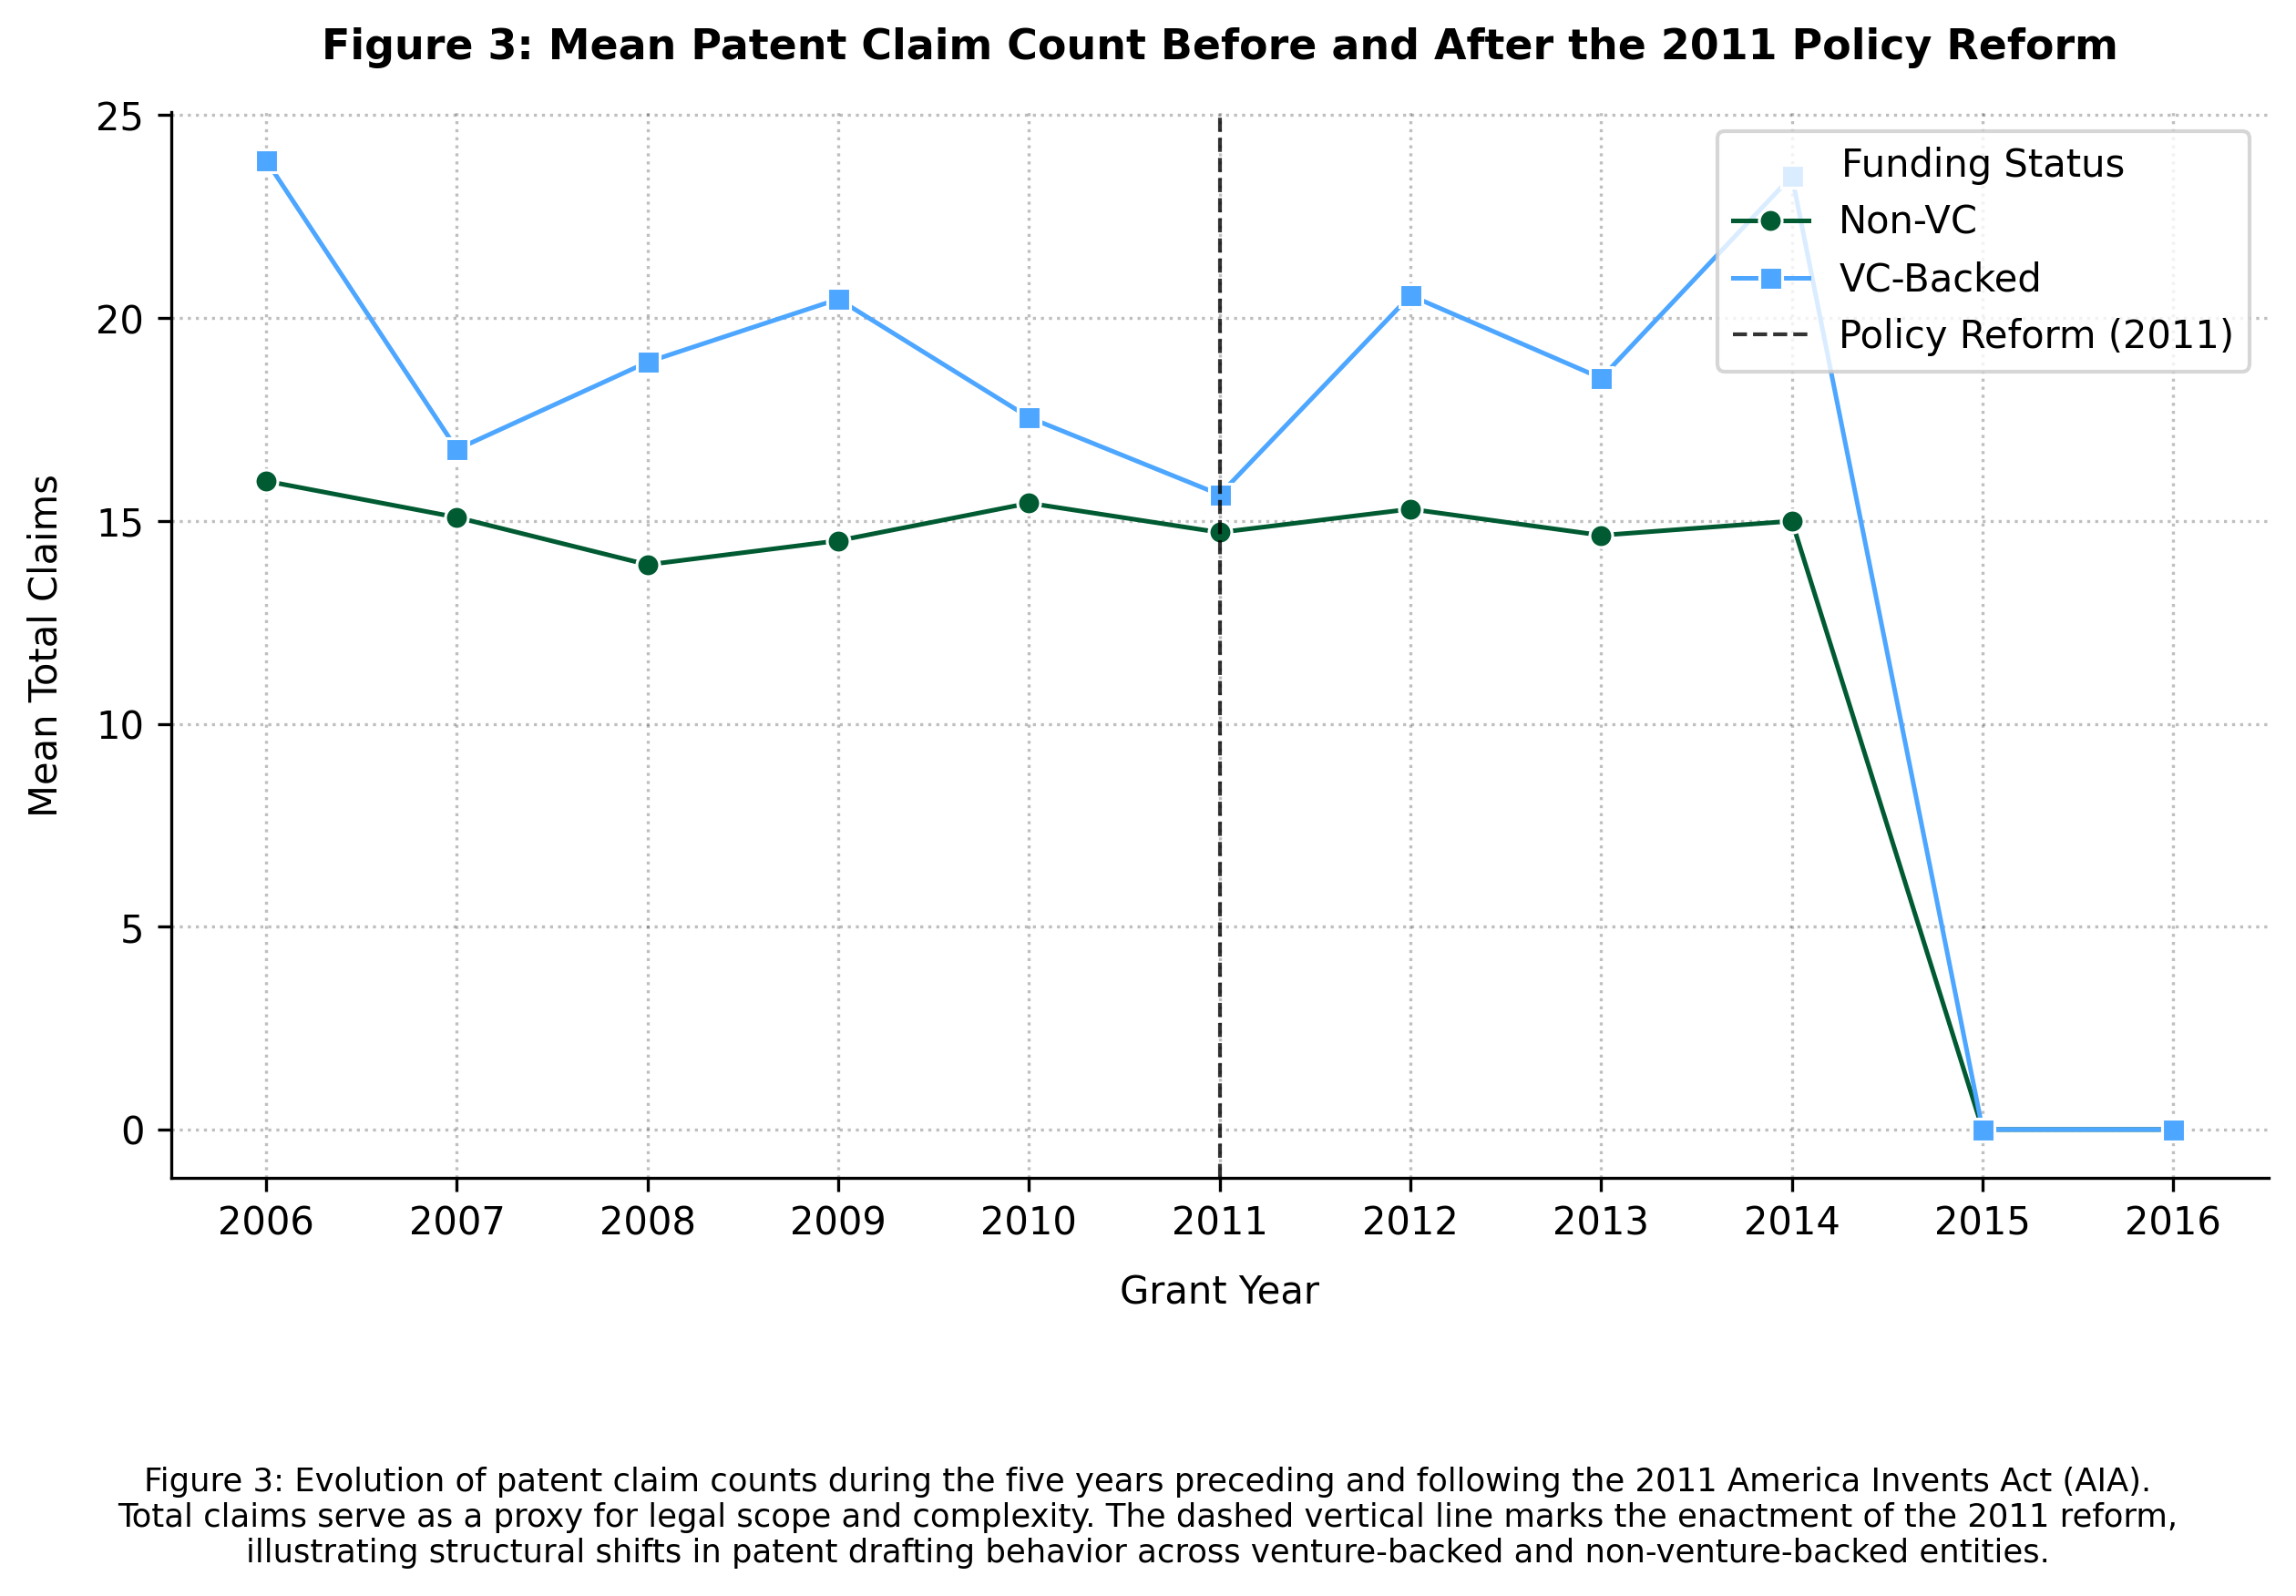

In [14]:
drive_data_dir = "/content/drive/MyDrive/data"
parquet_path = os.path.join(drive_data_dir, "cleaned_patent_panel.parquet")

con = duckdb.connect()

# 5 years pre- (2006-2010) and 5 years post- (2012-2016) policy change (2011)
df_claims_trend = con.execute(f"""
    SELECT
        grant_year,
        CASE WHEN vc_backed = 1 THEN 'VC-Backed' ELSE 'Non-VC' END AS vc_status,
        AVG(total_claims) AS mean_claims
    FROM '{parquet_path}'
    WHERE grant_year BETWEEN 2006 AND 2016
    GROUP BY grant_year, vc_backed
    ORDER BY grant_year;
""").df()

plt.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#000000',
    'grid.color': '#000000',
    'grid.alpha': 0.25
})

fig, ax = plt.subplots(figsize=(8.5, 5), dpi=300)

sns.lineplot(
    data=df_claims_trend,
    x='grant_year',
    y='mean_claims',
    hue='vc_status',
    style='vc_status',
    palette={'VC-Backed': '#4da6ff', 'Non-VC': '#005a32'},
    markers={'VC-Backed': 's', 'Non-VC': 'o'},
    dashes=False,
    linewidth=1.2,
    markersize=6,
    ax=ax
)

# vertical line marking the 2011 policy shift (Leahy-Smith America Invents Act)
ax.axvline(2011, color='#000000', linestyle='--', linewidth=1.0, alpha=0.8, label='Policy Reform (2011)')

ax.set_title('Figure 3: Mean Patent Claim Count Before and After the 2011 Policy Reform', fontsize=11, fontweight='bold', pad=14)
ax.set_xlabel('Grant Year', fontsize=10, labelpad=8)
ax.set_ylabel('Mean Total Claims', fontsize=10, labelpad=8)
ax.set_xticks(range(2006, 2017))
ax.grid(True, linestyle=':')

ax.legend(title='Funding Status', frameon=True, loc='upper right')

caption = (
    "Figure 3: Evolution of patent claim counts during the five years preceding and following the 2011 America Invents Act (AIA).\n"
    "Total claims serve as a proxy for legal scope and complexity. The dashed vertical line marks the enactment of the 2011 reform,\n"
    "illustrating structural shifts in patent drafting behavior across venture-backed and non-venture-backed entities."
)
plt.figtext(0.5, -0.15, caption, wrap=True, horizontalalignment='center', fontsize=8.5, color='#000000')

plt.tight_layout()

fig2_path = os.path.join(drive_data_dir, "figure3_claims_policy_trend.png")
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()